# **Perbandingan Algoritma Machine Learning dalam Memprediksi Traffic Volume pada Jalan Tol Interstate I-94 Menggunakan Data Cuaca dan Waktu**

# Sumber Dataset
Dataset yang digunakan berasal dari Kaggle, yaitu platform yang menyediakan berbagai dataset untuk pembelajaran dan penelitian di bidang data science dan machine learning.

Dataset ini berisi data volume lalu lintas pada jalan tol Metro Interstate dengan target traffic_volume, yang digunakan untuk menganalisis dan memprediksi jumlah kendaraan berdasarkan waktu, kondisi cuaca, dan hari libur.

# DATA UNDERSTANDING
Pada tahap Data Understanding, dilakukan pemahaman awal terhadap dataset yang digunakan. Proses ini meliputi melihat beberapa data pertama menggunakan head(), mengetahui informasi dataset seperti jumlah dan tipe data melalui info(), serta melihat statistik data numerik menggunakan describe(). Selain itu, dilakukan pengecekan terhadap missing value menggunakan isnull().sum() untuk memastikan tidak ada data yang kosong. Tahap ini bertujuan untuk memahami struktur dan kondisi data sebelum dilakukan proses pengolahan dan pemodelan lebih lanjut.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [ ]:
df = pd.read_excel('Metro_Interstate_Traffic_Volume.csv.xlsx')

print(df.columns)
df.head()

Index(['traffic_volume', 'holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all',
       'weather_main', 'weather_description', 'date_time'],
      dtype='object')


,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   traffic_volume       48204 non-null  int64         
 1   holiday              61 non-null     object        
 2   temp                 48204 non-null  float64       
 3   rain_1h              48204 non-null  float64       
 4   snow_1h              48204 non-null  float64       
 5   clouds_all           48204 non-null  int64         
 6   weather_main         48204 non-null  object        
 7   weather_description  48204 non-null  object        
 8   date_time            48204 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 3.3+ MB


,0
traffic_volume,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0


# PREPROCESSING
Pada tahap Data Preprocessing, dilakukan pengolahan data agar siap digunakan dalam pemodelan. Data kategorikal diubah menjadi numerik menggunakan Label Encoding, serta dilakukan pemisahan antara fitur (X) dan target (y).

In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['date_time'])

In [ ]:
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['day_of_week'] = df['date_time'].dt.dayofweek

In [ ]:
df = df.drop(['date_time'], axis=1)

In [ ]:
df.isnull().sum()

,0
traffic_volume,0
holiday,0
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
hour,0
day,0


In [37]:
from sklearn.preprocessing import LabelEncoder
import joblib # Import joblib for saving encoders

label_encoders = {}
categorical_cols = ['holiday', 'weather_main', 'weather_description']

for col in categorical_cols:
    le = LabelEncoder()
    # Convert to string to handle potential NaN values consistently as a category
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Label encoding complete for categorical columns.")
print("Please re-run all cells from 'FITUR DAN TARGET' (cell YpAWtq2KyATz) onwards to retrain models with the correct encoding.")

Label encoding complete for categorical columns.
Please re-run all cells from 'FITUR DAN TARGET' (cell YpAWtq2KyATz) onwards to retrain models with the correct encoding.


# EDA
Pada tahap Exploratory Data Analysis (EDA), dilakukan eksplorasi data untuk memahami distribusi dan pola dalam dataset. Visualisasi dilakukan menggunakan histogram untuk melihat distribusi traffic volume serta distribusi seluruh fitur. Selain itu, digunakan countplot untuk melihat frekuensi data kategorikal seperti holiday, weather_main, dan weather_description.
Selanjutnya, digunakan heatmap korelasi untuk mengetahui hubungan antar fitur dalam dataset. Tahap ini bertujuan untuk memahami pola data sebelum dilakukan pemodelan.

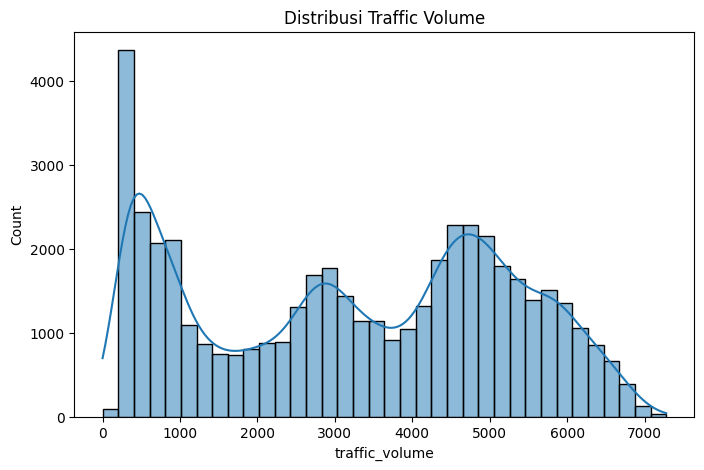

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['traffic_volume'], kde=True)
plt.title("Distribusi Traffic Volume")
plt.show()

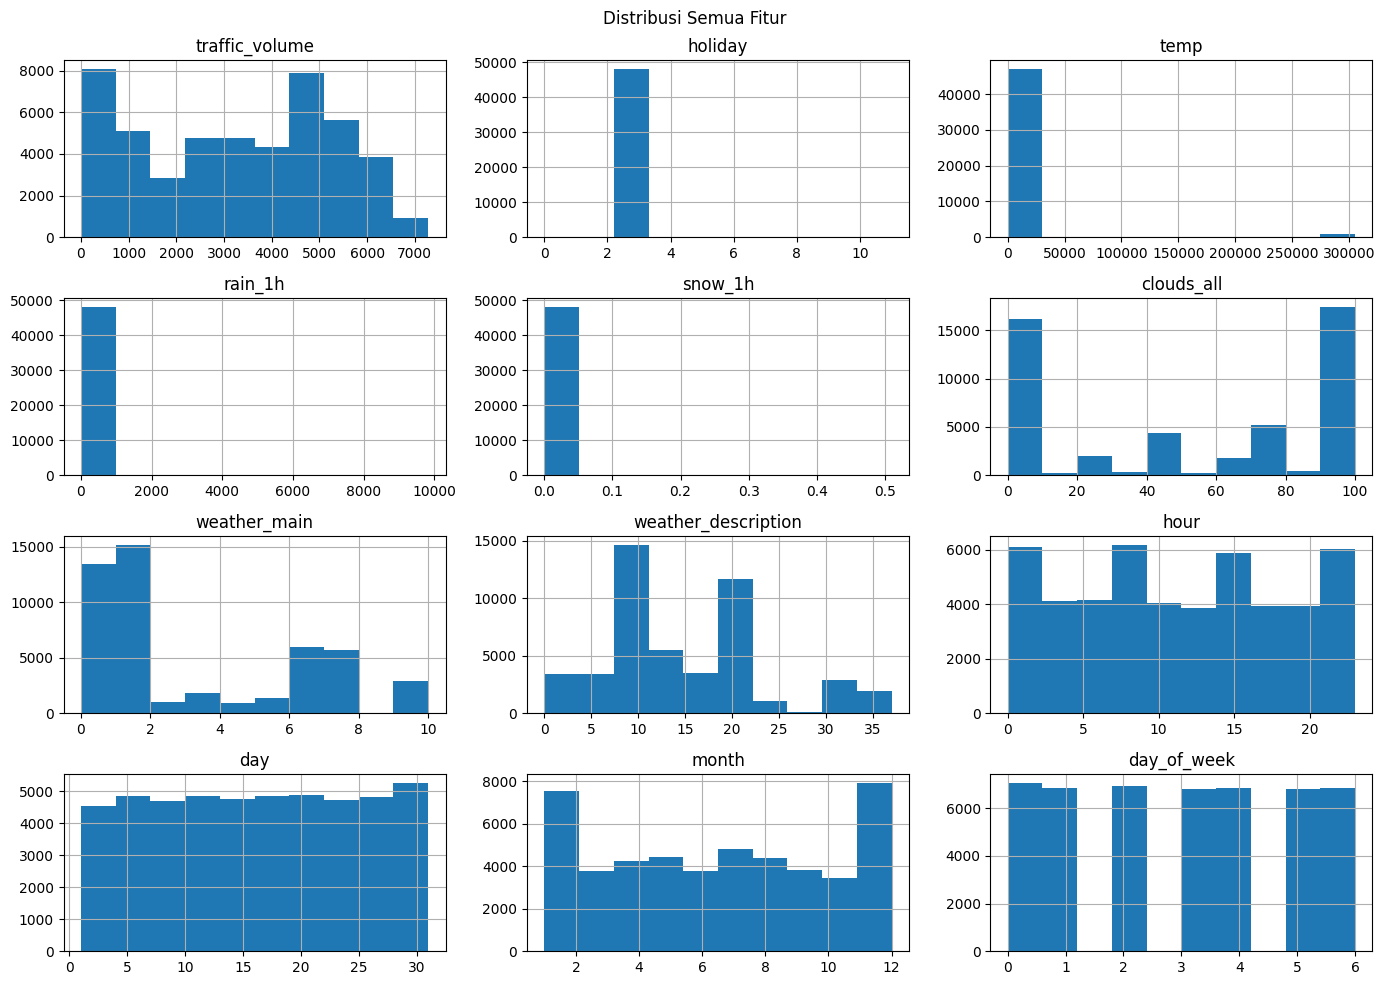

In [ ]:
df.hist(figsize=(14,10))
plt.suptitle("Distribusi Semua Fitur")
plt.tight_layout()
plt.show()

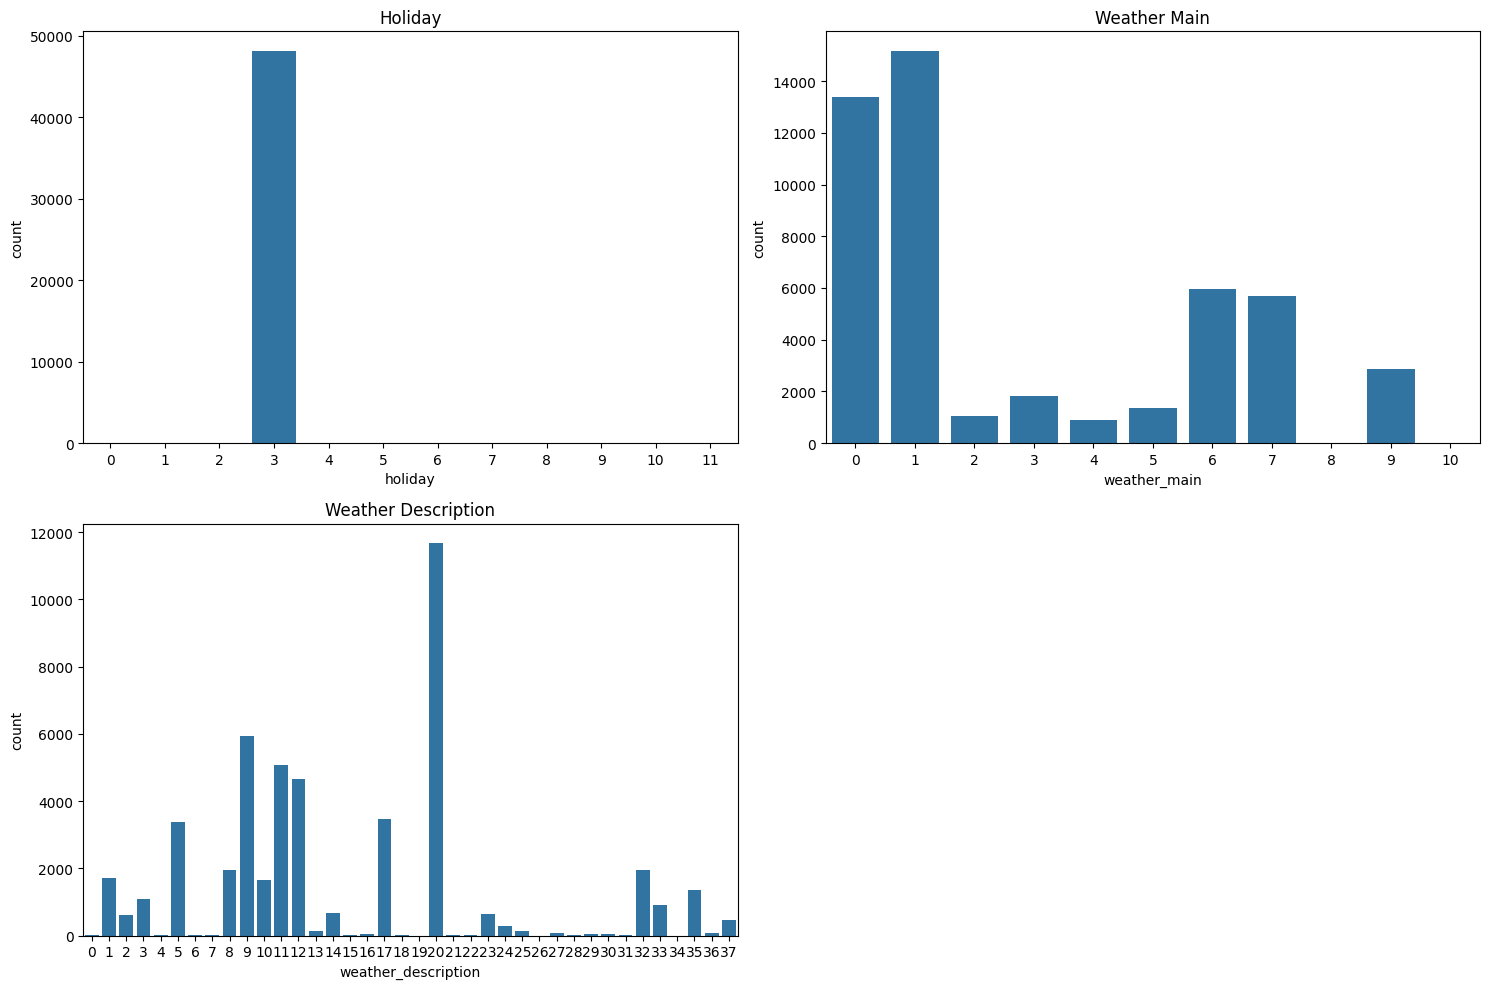

In [ ]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.countplot(x=df['holiday'])
plt.title("Holiday")

plt.subplot(2,2,2)
sns.countplot(x=df['weather_main'])
plt.title("Weather Main")

plt.subplot(2,2,3)
sns.countplot(x=df['weather_description'])
plt.title("Weather Description")

plt.tight_layout()
plt.show()

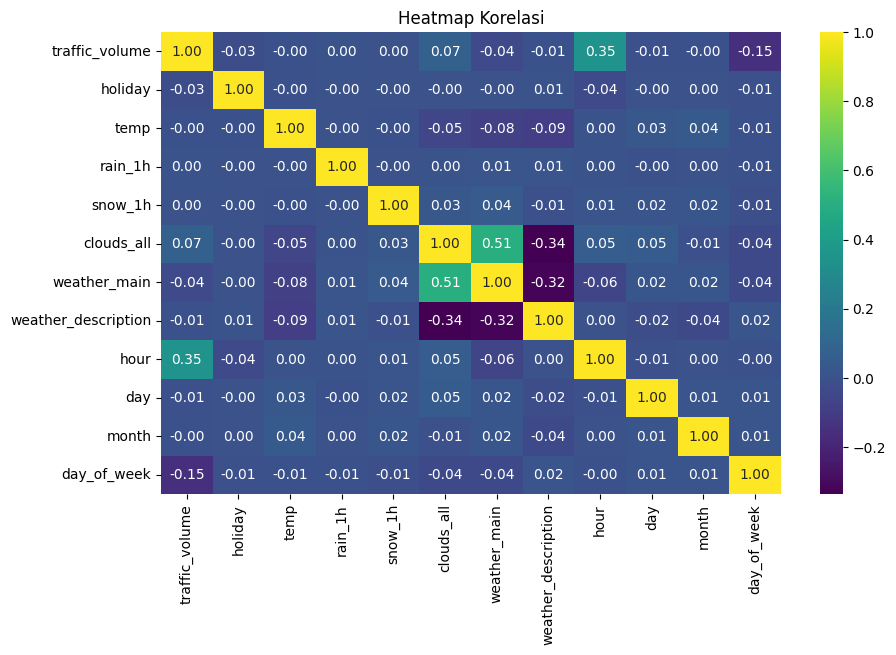

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='viridis')
plt.title("Heatmap Korelasi")
plt.show()

# FITUR DAN TARGET

Pada tahap ini dilakukan pemisahan antara fitur (X) dan target (y). Fitur merupakan seluruh variabel input yang digunakan untuk prediksi, sedangkan target adalah traffic_volume yang ingin diprediksi.



In [ ]:
X = df.drop('traffic_volume', axis=1)
y = df['traffic_volume']

# DATA SPLITTING
Pada tahap ini dataset dibagi menjadi data latih dan data uji menggunakan train_test_split(). Pembagian dilakukan dengan beberapa skenario rasio yaitu 70:30, 80:20, dan 90:10 untuk membandingkan performa model pada berbagai kondisi pembagian data.

In [ ]:
from sklearn.model_selection import train_test_split

splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

# MODEL DAN TUNING
Pada tahap Modeling, digunakan beberapa algoritma regresi yaitu Random Forest, Gradient Boosting, dan XGBoost. Setiap model diberikan parameter (hyperparameter tuning) seperti jumlah estimator, kedalaman pohon, dan learning rate untuk meningkatkan performa model dalam memprediksi traffic volume.

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42
    )
}

# EVALUASI & MODEL
Pada tahap Evaluasi, dilakukan pengukuran performa model menggunakan metrik seperti R² Score, Mean Absolute Error (MAE), dan Root Mean Squared Error (RMSE). Evaluasi dilakukan untuk setiap model dan setiap skenario pembagian data guna mengetahui model terbaik. Hasil evaluasi dari setiap model dan skenario splitting disimpan dalam bentuk tabel untuk memudahkan analisis. Data kemudian diurutkan berdasarkan nilai R² Score untuk melihat model dengan performa terbaik.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

results = []

for split_name, test_size in splits.items():
    print(f"\n=== SPLIT {split_name} ===")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        print(f"{model_name} | R2: {r2:.4f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")

        results.append({
            "Splitting": split_name,
            "Algorithm": model_name,
            "R2_Score": r2,
            "MAE": mae,
            "RMSE": rmse
        })


=== SPLIT 70:30 ===
XGBoost | R2: 0.9731 | MAE: 209.18 | RMSE: 326.90
Gradient Boosting | R2: 0.9581 | MAE: 251.00 | RMSE: 407.94
Random Forest | R2: 0.9614 | MAE: 230.83 | RMSE: 391.93

=== SPLIT 80:20 ===
XGBoost | R2: 0.9718 | MAE: 208.47 | RMSE: 333.76
Gradient Boosting | R2: 0.9571 | MAE: 248.57 | RMSE: 411.73
Random Forest | R2: 0.9603 | MAE: 228.01 | RMSE: 396.09

=== SPLIT 90:10 ===
XGBoost | R2: 0.9720 | MAE: 207.42 | RMSE: 333.35
Gradient Boosting | R2: 0.9565 | MAE: 250.68 | RMSE: 415.09
Random Forest | R2: 0.9600 | MAE: 227.15 | RMSE: 397.99


In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["Splitting", "R2_Score"],
    ascending=[True, False]
)

print("\n--- Tabel Perbandingan Akhir ---")
results_df


--- Tabel Perbandingan Akhir ---


,Splitting,Algorithm,R2_Score,MAE,RMSE
0,70:30,XGBoost,0.973126,209.183792,326.898947
2,70:30,Random Forest,0.961370,230.828321,391.931447
1,70:30,Gradient Boosting,0.958150,251.003023,407.940365
3,80:20,XGBoost,0.971824,208.474533,333.758673
5,80:20,Random Forest,0.960316,228.010746,396.094464
4,80:20,Gradient Boosting,0.957120,248.569620,411.734835
6,90:10,XGBoost,0.971967,207.417236,333.351764
8,90:10,Random Forest,0.960041,227.147048,397.989726
7,90:10,Gradient Boosting,0.956532,250.680116,415.094739


# GRAFIK
Pada tahap ini dilakukan visualisasi menggunakan grafik garis untuk membandingkan nilai R² Score antar model pada setiap skenario pembagian data. Grafik ini membantu dalam melihat performa model secara lebih jelas dan menentukan model terbaik.

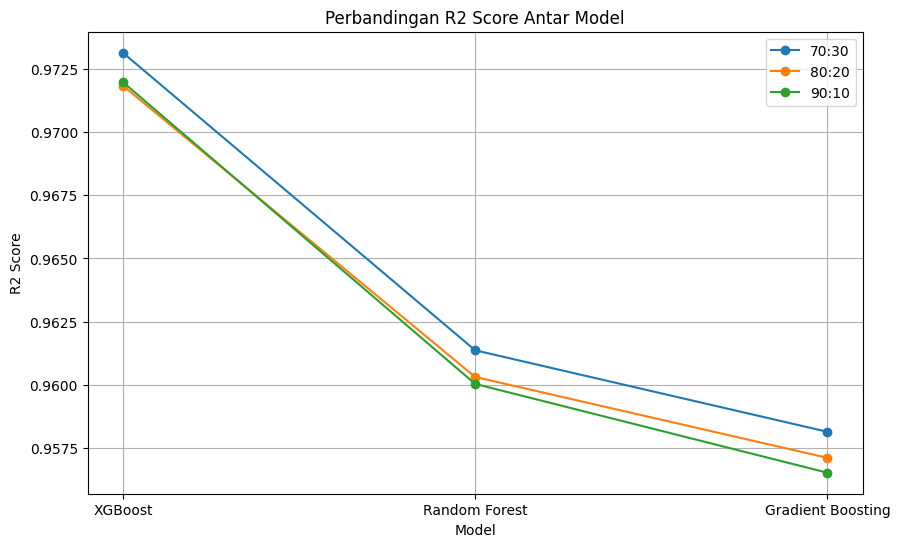

In [ ]:
plt.figure(figsize=(10,6))

for split in splits.keys():
    subset = results_df[results_df['Splitting'] == split]
    plt.plot(subset['Algorithm'], subset['R2_Score'], marker='o', label=split)

plt.title("Perbandingan R2 Score Antar Model")
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.legend()
plt.grid()
plt.show()

## Simpan Model Terbaik dan Encoder

Kita akan menyimpan model terbaik (XGBoost) dan `label_encoders` yang sudah dilatih agar dapat digunakan di aplikasi Streamlit. Kita juga akan menyimpan daftar nama fitur untuk memastikan urutan input yang benar.

In [42]:
import joblib
import pandas as pd

# Identifikasi model terbaik dari results_df (XGBoost consistently performs best)
best_model_name = results_df.loc[results_df['R2_Score'].idxmax()]['Algorithm']
best_model = models[best_model_name]

# Simpan model terbaik
joblib.dump(best_model, 'best_traffic_volume_model.pkl')
print(f"Model terbaik ({best_model_name}) berhasil disimpan sebagai 'best_traffic_volume_model.pkl'.")

# Simpan label encoders
joblib.dump(label_encoders, 'label_encoders.pkl')
print("Label encoders berhasil disimpan sebagai 'label_encoders.pkl'.")

# Simpan nama kolom fitur
feature_cols = X.columns.tolist()
joblib.dump(feature_cols, 'feature_columns.pkl')
print("Nama kolom fitur berhasil disimpan sebagai 'feature_columns.pkl'.")

Model terbaik (XGBoost) berhasil disimpan sebagai 'best_traffic_volume_model.pkl'.
Label encoders berhasil disimpan sebagai 'label_encoders.pkl'.
Nama kolom fitur berhasil disimpan sebagai 'feature_columns.pkl'.


## Membuat Aplikasi Streamlit

Berikut adalah kode untuk aplikasi Streamlit. Anda perlu menyimpan kode ini ke dalam file bernama `streamlit_app.py` dan menjalankannya dari terminal.

Pastikan Anda telah menginstal Streamlit (`pip install streamlit`) di lingkungan Anda.

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 92.0 MB/s eta 0:00:00


In [43]:
%%writefile streamlit_app.py

import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load the trained model, label encoders, and feature columns
model = joblib.load('best_traffic_volume_model.pkl')
label_encoders = joblib.load('label_encoders.pkl')
feature_columns = joblib.load('feature_columns.pkl')

# Streamlit app title
st.title('Prediksi Volume Lalu Lintas')
st.write('Aplikasi ini memprediksi volume lalu lintas berdasarkan kondisi cuaca, waktu, dan hari libyur.')

# Input fields for user
# Categorical features
holiday_options = label_encoders['holiday'].classes_
weather_main_options = label_encoders['weather_main'].classes_
weather_description_options = label_encoders['weather_description'].classes_

holiday = st.selectbox('Holiday', holiday_options)
weather_main = st.selectbox('Weather Main', weather_main_options)
weather_description = st.selectbox('Weather Description', weather_description_options)

# Numerical features
temp = st.slider('Temperature (Kelvin)', min_value=250.0, max_value=320.0, value=290.0, step=0.1)
rain_1h = st.number_input('Rain in last hour (mm)', min_value=0.0, max_value=100.0, value=0.0, step=0.01)
snow_1h = st.number_input('Snow in last hour (mm)', min_value=0.0, max_value=100.0, value=0.0, step=0.01)
clouds_all = st.slider('Clouds all (%)', min_value=0, max_value=100, value=50, step=1)
hour = st.slider('Hour of Day (0-23)', min_value=0, max_value=23, value=12, step=1)
day = st.slider('Day of Month (1-31)', min_value=1, max_value=31, value=15, step=1)
month = st.slider('Month (1-12)', min_value=1, max_value=12, value=7, step=1)
day_of_week = st.slider('Day of Week (0=Monday, 6=Sunday)', min_value=0, max_value=6, value=2, step=1)

# Create a button to make prediction
if st.button('Predict Traffic Volume'):
    # Encode categorical inputs
    encoded_holiday = label_encoders['holiday'].transform([holiday])[0]
    encoded_weather_main = label_encoders['weather_main'].transform([weather_main])[0]
    encoded_weather_description = label_encoders['weather_description'].transform([weather_description])[0]

    # Create a DataFrame for the input
    input_data = pd.DataFrame([[encoded_holiday, temp, rain_1h, snow_1h, clouds_all,
                                  encoded_weather_main, encoded_weather_description,
                                  hour, day, month, day_of_week]],
                                columns=feature_columns)

    # Make prediction
    prediction = model.predict(input_data)[0]

    st.success(f'Predicted Traffic Volume: {int(prediction):,}')

st.markdown("""
**How to run this app:**
1. Save the model, encoders, and feature columns using the cells above.
2. In your terminal, navigate to the directory where `streamlit_app.py` is saved.
3. Run `streamlit run streamlit_app.py`
""")

Overwriting streamlit_app.py
